<a href="https://colab.research.google.com/github/mel-oezkan/computer-vision-proj-lab/blob/Jiaqi/Plucker_encode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prepare co_3d

In [ ]:
!pip install open3d

In [2]:
import os
import sys
import random
import numpy as np
import torch
import subprocess
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


In [ ]:
!pip install visdom  requests h5py
!git clone https://github.com/facebookresearch/co3d.git
%cd /content/co3d
!pip install -e .

In [4]:
import co3d
print(co3d.__file__)

/content/co3d/co3d/__init__.py


In [5]:
%cd ..
print(os.getcwd())


/content
/content


In [ ]:
ROOT_DIR=os.path.join(os.getcwd(),"co3d_data")
if not os.path.exists(ROOT_DIR):
    os.mkdir(ROOT_DIR)
print(ROOT_DIR)


!python /content/co3d/co3d/download_dataset.py --download_folder  $ROOT_DIR --single_sequence_subset


# Dataset

In [ ]:
!pip install ipdb

## prepare the bbox for the "bench" in each frame
(bench)


*   this part will be done before the plucker
encoding by entering command

> python -m preprocess.preprocess_co3d --category all --precompute_bbox \
        --co3d_v2_dir /path/to/co3d_v2
to pre-compute the bbox since this takes a long time

*   in notebook, we choose /content  as the output path for bbox


In [12]:

from glob import glob
import gzip
import ipdb
import json

def mask_to_bbox(mask):
    """
    xyxy format
    """
    mask = mask > 0.4
    if not np.any(mask):
        return []
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return [int(cmin), int(rmin), int(cmax) + 1, int(rmax) + 1]

def precompute_bbox(co3d_dir, category, output_dir):
    """
    Precomputes bounding boxes for all frames using the masks. This can be an expensive
    operation because it needs to load every mask in the dataset. Thus, we only want to
    run this once, whereas processing the rest of the dataset is fast.
    """
    category_dir = os.path.join(co3d_dir, category)
    print("Precomputing bbox for:", category)
    all_masks = sorted(glob(os.path.join(category_dir, "*", "masks", "*.png")))
    bboxes = {}
    for mask_filename in tqdm(all_masks):
        mask = plt.imread(mask_filename)
        # /Dataset/category/sequence/masks/mask.png -> category/sequence/mask/mask.png
        mask_filename = mask_filename.replace(os.path.dirname(category_dir), "")[1:]
        try:
            bboxes[mask_filename] = mask_to_bbox(mask)
        except IndexError:
            ipdb.set_trace()
    output_file = os.path.join(output_dir, f"{category}_bbox.jgz")
    with gzip.open(output_file, "w") as f:
        f.write(json.dumps(bboxes).encode("utf-8"))

In [13]:
bbox_info=precompute_bbox(co3d_dir=ROOT_DIR, category="bench",output_dir=os.getcwd())

Precomputing bbox for: bench


  0%|          | 0/606 [00:00<?, ?it/s]

In [14]:
from typing import Optional
from torch.utils.data import Dataset,DataLoader
import gzip

from PIL import Image
import numpy as np
from torchvision import transforms as transforms
from typing import List
from co3d.dataset.data_types import load_dataclass_jgzip, FrameAnnotation, SequenceAnnotation
import json
import warnings

CO3D_ANNOTATION_DIR=os.getcwd()


CATEGORIES = [
    "apple", "backpack", "ball", "banana", "baseballbat", "baseballglove",
    "bench", "bicycle", "book", "bottle", "bowl", "broccoli", "cake", "car", "carrot",
    "cellphone", "chair", "couch", "cup", "donut", "frisbee", "hairdryer", "handbag",
    "hotdog", "hydrant", "keyboard", "kite", "laptop", "microwave", "motorcycle",
    "mouse", "orange", "parkingmeter", "pizza", "plant", "remote", "sandwich",
    "skateboard", "stopsign", "suitcase", "teddybear", "toaster", "toilet", "toybus",
    "toyplane", "toytrain", "toytruck", "tv", "umbrella", "vase", "wineglass",
]

#image augmentation
def jitter_bbox(square_bbox, jitter_scale=(1.1, 1.2), jitter_trans=(-0.07, 0.07)):
    square_bbox = np.array(square_bbox.astype(float))
    s = np.random.uniform(jitter_scale[0], jitter_scale[1])
    tx, ty = np.random.uniform(jitter_trans[0], jitter_trans[1], size=2)
    side_length = square_bbox[2] - square_bbox[0]
    center = (square_bbox[:2] + square_bbox[2:]) / 2 + np.array([tx, ty]) * side_length
    extent = side_length / 2 * s
    ul = center - extent
    lr = ul + 2 * extent
    return np.concatenate((ul, lr))

def square_bbox(bbox, padding=0.0, astype=None):
    """
    Computes a square bounding box, with optional padding parameters.
    Args:
        bbox: Bounding box in xyxy format (4,).
    Returns:
        square_bbox in xyxy format (4,).
    """
    if astype is None:
        astype = type(bbox[0])
    bbox = np.array(bbox)
    center = (bbox[:2] + bbox[2:]) / 2
    extents = (bbox[2:] - bbox[:2]) / 2
    s = max(extents) * (1 + padding)
    square_bbox = np.array(
        [center[0] - s, center[1] - s, center[0] + s, center[1] + s],
        dtype=astype,
    )
    return square_bbox


class CO3D_Dataset(Dataset):
    def __init__(self,
                 root_dir:str,
                 category:str,
                 subset_name:str, #"test_0" / "dev_0" / "dev_1"
                 subset:str ="train", #"train"/"test"/"val"
                 transform=None,
                 crop_images=True,
                 apply_augmentation=True,

                 ) :
        super().__init__()
        self.root_dir=root_dir
        self.category=category
        self.transform=transform
        self.crop_images=crop_images
        self.apply_augmentation=apply_augmentation
        self.transform=transform

        if self.transform is None:
            self.transform=transforms.Compose([
               transforms.Resize((512,512),antialias=True),
               transforms.ToTensor(),
               transforms.Normalize([0.5], [0.5]),
        ])

        if self.apply_augmentation:
            self.jitter_scale = (1.1, 1.2)
            self.jitter_trans = (-0.07, 0.07)
        else:
            # Note if trained with apply_augmentation, we should still use
            # apply_augmentation at test time.
            self.jitter_scale = (1, 1)
            self.jitter_trans = (0.0, 0.0)

        #load bbox data
        bbox_file=os.path.join(CO3D_ANNOTATION_DIR, f'{self.category}_bbox.jgz')
        with gzip.open(bbox_file, "r") as fin:
            self.bbox_data = json.loads(fin.read())

        #load the frame_annotation of the category
        frame_ann_path=os.path.join(root_dir,category,"frame_annotations.jgz")
        self.frames_ann=load_dataclass_jgzip(frame_ann_path,
                                             List[FrameAnnotation])

        #load the sequence_annotation of the category
        sequence_ann_path=os.path.join(root_dir,category,"sequence_annotations.jgz")
        self.seq_ann=load_dataclass_jgzip(sequence_ann_path,List[SequenceAnnotation])
        self.seq_dict={seq.sequence_name: seq for seq in self.seq_ann}


        #filter the subset
        set_files = [
            f for f in os.listdir(os.path.join(root_dir, category,"set_lists"))
            if f.startswith("set_lists_manyview_") and f.endswith(".json")
        ]
        if not set_files:
            raise RuntimeError(f"No set_lists_manyview_*.json files found in {category}.")


        subset_file=f"set_lists_manyview_{subset_name}.json"
        if subset_file not in set_files:
            warnings.warn(f"set_lists_manyview_{subset_name}.json doesn't exist,choose the test sequence(no pointcloud)")

            subset_file=f"set_lists_manyview_test_0.json"

        sub_type=str(subset_file).split('_')[3]
        if sub_type=="dev":
            self.is_dev=True
        else:
            self.is_dev=False

        set_list_path=os.path.join(root_dir,category,"set_lists",subset_file)

        with open(set_list_path,'r')as f:
             set_lists = json.load(f)
        subset_items = set_lists.get(subset, [])

        self.sequence_name=subset_items[0][0]

        #create the list of frames
        self.samples=[]
        for(_,frame_number,img_path) in subset_items:
            full_img_path=os.path.join(root_dir,img_path)
            self.samples.append((frame_number,full_img_path))

    def __len__(self):
        return len(self.samples)

    def _crop_image(self, image, bbox):
        image_crop = transforms.functional.crop(
            image,
            top=bbox[1],
            left=bbox[0],
            height=bbox[3] - bbox[1],
            width=bbox[2] - bbox[0],
        )
        return image_crop

    def __getitem__(self,index):
        frame_num,img_path=self.samples[index]

        #image
        image_i=Image.open(img_path).convert("RGB")
        # if self.transform:
        #     image=self.transform(image_i)
        # else:                        #(H,W,C).       (C,H,W)
        image=torch.from_numpy(np.array(image_i)).permute(2,0,1).float() / 255.0 #value in [0,1]
        original_size=(image.shape[1], image.shape[2])

        #mask
        mask_path=img_path.replace("/images/","/masks/").replace("jpg","png")
        mask=Image.open(mask_path) if os.path.exists(mask_path) else None
        mask= torch.from_numpy(np.array(mask)).unsqueeze(0).float() /255.0 if mask else None

        #bbox
        bbox=self.bbox_data[mask_path.replace(os.path.join(ROOT_DIR,''),'')] #[int(cmin), int(rmin), int(cmax) + 1, int(rmax) + 1]
        bbox_init=( bbox if self.crop_images else [0, 0, image_i.width, image_i.height])
        bbox = square_bbox(np.array(bbox_init))

        if self.apply_augmentation:
            bbox = jitter_bbox(
                        bbox,
                        jitter_scale=self.jitter_scale,
                        jitter_trans=self.jitter_trans,
                    )
        bbox = np.around(bbox).astype(int)

        #crop parameters
        crop_center = (bbox[:2] + bbox[2:]) / 2
        # convert crop center to correspond to a "square" image
        width, height = image_i.size
        length = max(width, height)
        s = length / min(width, height)
        crop_center = crop_center + (length - np.array([width, height])) / 2
        # convert to NDC
        cc = s - 2 * s * crop_center / length
        crop_width = 2 * s * (bbox[2] - bbox[0]) / length
        crop_params = torch.tensor([-cc[0], -cc[1], crop_width, s],dtype=torch.float32)

        #crop and normalize the image
        image_cropped=self._crop_image(image=image_i, bbox=bbox)
        image_cropped=self.transform(image_cropped)
        cropped_size=(image_cropped.shape[1],image_cropped.shape[2])



        #depth
        depth_path=img_path.replace("/images/","/depths/")
        depth_path= str(depth_path) + ".geometric.png"
        depth=Image.open(depth_path) if os.path.exists(depth_path) else None
        depth=torch.from_numpy(np.array(depth)).unsqueeze(0).float() if depth else None

        #depth mask
        depth_mask_path=img_path.replace("/images/","/depth_masks/").replace(".jpg",".png")
        depth_mask=Image.open(depth_mask_path) if os.path.exists(depth_mask_path) else None
        depth_mask= torch.from_numpy(np.array(depth_mask)).unsqueeze(0).float() /255.0 if depth_mask else None

        #viewpoint
        frame= next(
            (f for f in self.frames_ann if f.sequence_name==self.sequence_name and f.frame_number==frame_num) ,None
            )

        if frame is not None:
            vp=frame.viewpoint
            R=torch.tensor(vp.R,dtype=torch.float32)
            T=torch.tensor(vp.T,dtype=torch.float32)
            focal_length=torch.tensor(vp.focal_length,dtype=torch.float32)
            principle_point=torch.tensor(vp.principal_point,dtype=torch.float32)
            scale_adjustment=frame.depth.scale_adjustment
        else:
            R=T=focal_length=principle_point=scale_adjustment=None

        #pointcloud

        if not self.is_dev:
            pointcloud=None
        else:
            seq_ann=self.seq_dict.get(self.sequence_name)
            if seq_ann and seq_ann.point_cloud:
                import open3d
                pc_path = seq_ann.point_cloud.path
                pc_score = seq_ann.point_cloud.quality_score
                pc_num_points = seq_ann.point_cloud.n_points

                pcd_full_path = os.path.join(self.root_dir,pc_path)
                if os.path.exists(pcd_full_path):
                    pcd=open3d.io.read_point_cloud(pcd_full_path)
                    points=np.asarray(pcd.points)
                    pointcloud=torch.from_numpy(points).float()
                else:
                    pointcloud=None

            else:
                pointcloud=None

        return {
            "category":self.category,
            "image": image,
            "original_size":original_size,
            "mask" : mask,
            "depth": depth,
            "scale_adjustment":scale_adjustment,
            "depth_mask": depth_mask,
            "R": R,
            "T": T,
            "focal_length": focal_length,
            "principle_point": principle_point,
            "pointcloud":pointcloud,
            "sequence_name": self.sequence_name,
            "frame_numer": frame_num,
            "cropped_image": image_cropped,
            "cropped_size": cropped_size,
            "crop_params": crop_params,
        }

    def get_all_images(self):
        all_images=[]
        iterator=tqdm(range(len(self)),desc="Loading all images")

        for i in iterator:
            sample=self[i]
            img=sample['image']
            all_images.append(img)
        return all_images


    def get_all_R(self):
        all_R=[]
        iterator=tqdm(range(len(self)),desc="Loading all R")
        for i in iterator:
            sample=self[i]
            R=sample["R"]
            all_R.append(R)
        return all_R

    def get_all_T(self):
        all_T=[]
        iterator=tqdm(range(len(self)),desc="Loading all T")
        for i in iterator:
            sample=self[i]
            T=sample["T"]
            all_T.append(T)
        return all_T

    def get_all_RT(self):
        all_RT=[]
        iterator=tqdm(range(len(self)),desc="Loading all R,T")
        for i in iterator:
            sample=self[i]
            R=sample["R"]
            T=sample["T"]
            all_RT.append({"R":R , "T": T})
        return all_RT











In [15]:
def co3d_collate_func(batch):
    collated={}
    keys=batch[0].keys()
    for key in keys:
        values=[b[key] for b in batch]
        if isinstance(values[0],torch.Tensor):
            try:
                collated[key]=torch.stack(values)
            except:
                collated[key]=values

        else:
            collated[key]=values
    return collated

## prepare dataset for samples from "bench"

In [16]:
dataset=CO3D_Dataset(root_dir=ROOT_DIR,
                     category="bench",
                     subset_name="dev_0",
                     subset="train")
dl=DataLoader(dataset=dataset,collate_fn=co3d_collate_func,batch_size=8)


torch.Size([8, 3, 512, 512])


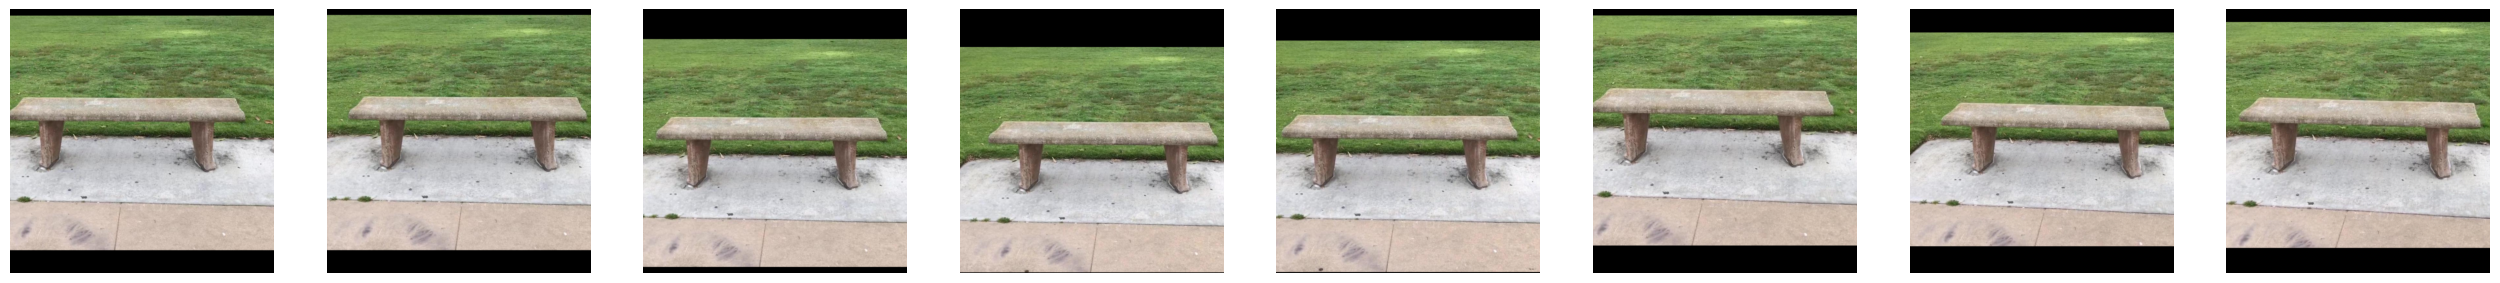

tensor([[ 0.1969,  0.0689,  2.2475,  1.7792],
        [-0.0113,  0.0717,  2.2419,  1.7792],
        [ 0.0802, -0.1055,  2.3179,  1.7792],
        [-0.0816, -0.1660,  2.3432,  1.7792],
        [ 0.0563, -0.1322,  2.2813,  1.7792],
        [ 0.0450,  0.0914,  2.2982,  1.7792],
        [-0.2096,  0.0155,  2.4698,  1.7792],
        [-0.1125,  0.0534,  2.3376,  1.7792]]) torch.Size([8, 4])
torch.Size([8, 3, 3])
torch.Size([8, 3])
tensor([[-0.0000, -0.0014],
        [-0.0000, -0.0014],
        [-0.0000, -0.0014],
        [-0.0000, -0.0014],
        [-0.0000, -0.0000],
        [ 0.0014, -0.0000],
        [ 0.0014, -0.0000],
        [-0.0000, -0.0014]]) torch.Size([8, 2])
tensor([[3.5028, 3.5028],
        [3.5065, 3.5065],
        [3.5091, 3.5091],
        [3.5084, 3.5084],
        [3.5062, 3.5062],
        [3.5065, 3.5065],
        [3.5085, 3.5085],
        [3.5003, 3.5003]]) torch.Size([8, 2])
first original frame size: (711, 1265)
711
first cropped frame size: (512, 512)


In [25]:
sample=next(iter(dl))
image_cropped=sample["cropped_image"]
print(image_cropped.shape)
# plt.figure(figsize=(6,8))
# plt.imshow(image_cropped)
#show cropped images
fig, axs = plt.subplots(1, image_cropped.shape[0],figsize=(4*image_cropped.shape[0],4))
for i,img in enumerate(image_cropped):
    ax=axs[i]
    img=(img +1)/2
    img=img.permute(1,2,0)
    ax.imshow(img)
    ax.axis("off")
plt.show()

crop_params=sample["crop_params"]
R=sample['R']
T=sample['T']
principle_point=sample['principle_point']
focal_length=sample['focal_length']
orig_h,orig_w=sample['original_size'][0][0], sample['original_size'][0][1]

print(crop_params,crop_params.shape)
print(R.shape)
print(T.shape)
print(principle_point,principle_point.shape)
print(focal_length,focal_length.shape)
print(f'first original frame size: {sample['original_size'][0]}')
print(orig_h)
print(f'first cropped frame size: {sample['cropped_size'][0]}')



# plücker

In [20]:
from torchvision.transforms.functional import crop
def update_intrinsics_after_crop(
    focal_length,
    principle_point,
    crop_params,
    original_image_size,
    cropped_image_size,
):
    """
    focal_length: (fx,fy)
    principle_point : (cx,cy)
    crop_params: [-cc[0], -cc[1], crop_width, s]
    original_image_size: tuple(orig_h, orig_w)
    cropped_image_size: tuple(cropped_h, cropped_w) final resized cropped window

    """
    orig_h, orig_w=original_image_size[0],original_image_size[1]

    cropped_h, cropped_w=cropped_image_size[0],cropped_image_size[1]

    tx, ty, crop_width, s= crop_params.tolist()

    length=max(orig_h,orig_w)

    pad_x= (length - orig_w) /2.0
    pad_y= (length - orig_h) /2.0

    fx=focal_length[0]
    fy=focal_length[1]

    cx=principle_point[0] + pad_x
    cy=principle_point[1] + pad_y

    # bbox (cropped window) in the padded pixel space
    bbox_w= crop_width * length
    bbox_h=bbox_w

    #cropped_center in the padded pixel space
    cropped_cx= (-tx *length / 2.0 + length / 2.0)
    cropped_cy= (-ty *length / 2.0 + length / 2.0)

    #upper-left corner of cropped window in the padded pixel space
    ul_cx= cropped_cx - bbox_w/2.0
    ul_cy= cropped_cy - bbox_h/2.0

    #find the pp in the cropped coordinate
    new_cx= cx -ul_cx
    new_cy= cy -ul_cy

    #scale intrinsics into the size of resized cropped window

    x_scale= cropped_w / bbox_w
    y_scale= cropped_h / bbox_h

    fx= fx * x_scale
    fy= fy * y_scale

    new_cx= new_cx * x_scale
    new_cy= new_cy * y_scale

    return torch.tensor([fx,fy]) , torch.tensor([new_cx,new_cy])


def create_grid(
    H,
    W,
    device,
    patch_num=16, #if None, no patch



   ):
    grids=[]
    if patch_num is not None:

        dh= H //patch_num
        dw= W //patch_num


        for i in range(patch_num):
            for j in range(patch_num):
                u0,u1= j* dw, (j+1) * dw
                v0,v1= i* dh, (i+1) * dh

                u=torch.arange(u0,u1,device=device)
                v=torch.arange(v0,v1,device=device)

                vv,uu=torch.meshgrid(v,u,indexing='ij')

                pixel_grid=torch.stack([uu,vv,torch.ones_like(uu)],dim=-1)

                grids.append(pixel_grid) #(dh,dw,3)

        return torch.stack(grids) #(patch_num ^2 , dh, dw, 3)

    else:
        u=torch.arange(H,device=device)
        v=torch.arange(W,device=device)

        vv,uu = torch.meshgrid(v,u,indexing='ij')

        pixel_grid=torch.stack([uu,vv,torch.ones_like(uu)],dim=-1)
        return pixel_grid #(H,W,3)




def plucker_from_all_pixels(R , T , pixel_grid, fl, pp ):
    """
    R: (3,3)
    T: (3,)
    fl: (2,)
    pp: (2,)
    pixel_grid : (H,W, 3)
    """
    u= pixel_grid[...,0] #(H,W)
    v= pixel_grid[...,1]

    H,W=u.shape
    N=H*W

    u=u.reshape(N)
    v=v.reshape(N)



    #convert pixel into camera cooridnate
    cx,cy=pp[0],pp[1]
    fx,fy=fl[0],fl[1]

    x=(u-cx) / fx #(N)
    y=(v-cy) / fy

    z=torch.ones_like(x)

    dir_cam= torch.stack([x,y,z],dim=-1) #(N,3)
    #dir_cam= torch.nn.functional.normalize(dir_cam,dim=-1)

    dir_world= dir_cam @ R #(N,3)

    C_world= -T @ R.T #(3)

    m_world= torch.cross(C_world.expand_as(dir_world), dir_world,dim=-1) #(N,3)

    return torch.cat([dir_world,m_world],dim=-1) #(N,6)


def plucker_from_single_pixels(R , T ,  fl, pp,u,v ):
    """
    R: (3,3)
    T: (3,)
    fl: (2,)
    pp: (2,)
    u ,v: constant
    """



    #convert pixel into camera cooridnate
    cx,cy=pp[0],pp[1]
    fx,fy=fl[0],fl[1]

    x=(u-cx) / fx
    y=(v-cy) / fy

    z= 1.0

    dir_cam= torch.tensor([x,y,z])
    #dir_cam= dir_cam / torch.norm(dir_cam)

    dir_world= dir_cam @ R #(3,)

    C_world= -T @ R.T #(3,)

    m_world= torch.cross(C_world, dir_world,dim=-1) #(3,)

    return torch.cat([dir_world,m_world],dim=-1) #(6,)


def plucker_from_patches(R , T , pixel_grid, fl, pp):
    """
    R: (3,3)
    T: (3,)
    fl: (2,)
    pp: (2,)
    pixel_grid : (P=patch_num^2, dh, dw, 3)
    """

    # take the center pixel of each patch to calculate the plucker
    P, dh , dw,_ =pixel_grid.shape
    cen_x= dw //2
    cen_y= dh //2

    centers=pixel_grid[:,cen_x, cen_y , :] #(P,3)
    print(f'centers shape:{centers.shape}')

    P= centers.shape[0]

    pluckers=[]

    for i in range(P):
        u,v,_ = centers[i]
        plucker=plucker_from_single_pixels(R=R,
                                           T=T,
                                           fl=fl,
                                           pp=pp,
                                           u=u,
                                           v=v)
        pluckers.append(plucker)

    print(f'plucker shape: {pluckers[0].shape}')
    return torch.stack(pluckers,dim=0) #(P,6)



def plucker_encodeing(R,
                      T,
                      fl,
                      pp,
                      crop_params,
                      original_size,
                      cropped_size,
                      device,
                      patch_num=None):
    fl,pp=update_intrinsics_after_crop(focal_length=fl,
                                       principle_point=pp,
                                       crop_params=crop_params,
                                       original_image_size=original_size,
                                       cropped_image_size=cropped_size,
                                       )
    H,W=cropped_size


    pixel_grid=create_grid(H,W,device=device,patch_num=patch_num)

    if patch_num is None:
        return plucker_from_all_pixels(R=R,
                                       T=T,
                                       pixel_grid=pixel_grid,
                                       fl=fl,
                                       pp=pp

                                       )
    else:
        return plucker_from_patches(R=R,
                                    T=T,
                                    pixel_grid=pixel_grid,
                                    fl=fl,
                                    pp=pp)









# Test

In [26]:
samples=next(iter(dl))

cropped_images=samples["cropped_image"]
original_size=samples["original_size"][0]
cropped_size=samples["cropped_size"][0]
crop_params=samples["crop_params"]
Rs=samples["R"]
Ts=samples["T"]
pps=samples["principle_point"]
fls=samples["focal_length"]






print(cropped_images.shape)

print(original_size)
print(cropped_size)
print(crop_params)

print(Rs.shape)
print(Ts.shape)
print(pps.shape)
print(fls.shape)

device=torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")



torch.Size([8, 3, 512, 512])
(711, 1265)
(512, 512)
tensor([[ 0.1435,  0.0788,  2.3994,  1.7792],
        [ 0.1603, -0.0127,  2.2419,  1.7792],
        [ 0.1350, -0.0253,  2.2869,  1.7792],
        [-0.0183,  0.0956,  2.2447,  1.7792],
        [-0.1421, -0.0759,  2.2954,  1.7792],
        [ 0.0774,  0.0155,  2.2954,  1.7792],
        [ 0.0084, -0.0844,  2.5288,  1.7792],
        [ 0.0253,  0.1308,  2.3994,  1.7792]])
torch.Size([8, 3, 3])
torch.Size([8, 3])
torch.Size([8, 2])
torch.Size([8, 2])


## all_pixel_encoding

In [27]:
pluckers=[]
for R,T,pp,fl,crop_param in zip(Rs, Ts, pps, fls, crop_params ):
    plucker=plucker_encodeing(R,T,fl,pp,crop_param,
                            original_size=original_size,
                            cropped_size=cropped_size,
                            device=device
                            )
    pluckers.append(plucker)

print(len(pluckers))
print(pluckers[0].shape)



8
torch.Size([262144, 6])


## patch_encoding

In [28]:
pluckers_p=[]
for R,T,pp,fl,crop_param in zip(Rs, Ts, pps, fls, crop_params ):
    plucker=plucker_encodeing(R,T,fl,pp,crop_param,
                            original_size=original_size,
                            cropped_size=cropped_size,
                            device=device,
                            patch_num=16
                            )
    pluckers_p.append(plucker)

print(len(pluckers_p))
print(pluckers_p[0].shape) #the shape of the first plucker of each batch



centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
centers shape:torch.Size([256, 3])
plucker shape: torch.Size([6])
8
torch.Size([256, 6])


## Validation (visual)

4th R: tensor([[-0.9998,  0.0029,  0.0202],
        [-0.0031, -0.9999, -0.0111],
        [ 0.0202, -0.0112,  0.9997]]),T:tensor([-0.0603,  0.5242, 10.6279])
0th R: tensor([[-1.0000,  0.0044,  0.0061],
        [-0.0046, -0.9997, -0.0257],
        [ 0.0060, -0.0257,  0.9997]]),T:tensor([-0.2917,  0.3789, 10.7048])
C_4:tensor([ -0.2770,   0.6423, -10.6180]), C_0:tensor([ -0.3592,   0.6524, -10.6895])


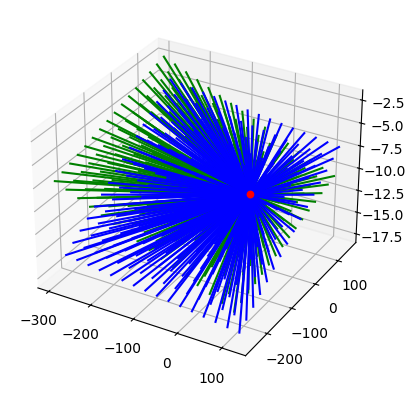

In [73]:
from matplotlib import pyplot as plt


# take the 0th and the 4th camera pose to test

ds_0=[]
ms_0=[]
ds_4=[]
ms_4=[]
pluckers_of_firstIm=pluckers_p[0]
pluckers_of_lastIm=pluckers_p[4]

for plucker_0, plucker_4 in zip(pluckers_of_firstIm,pluckers_of_lastIm):
    #print(plucker.shape)
    ds_0.append(plucker_0[:3])
    ms_0.append(plucker_0[3:])

    ds_4.append(plucker_4[:3])
    ms_4.append(plucker_4[3:])
# print(ds[1].shape)
# print(ms[1].shape)

R_sample_4=Rs[4]
T_sample_4=Ts[4]

R_sample_0=Rs[0]
T_sample_0=Ts[0]

print(f'4th R: {R_sample_4},T:{T_sample_4}')
print(f'0th R: {R_sample_0},T:{T_sample_0}')



C_4= - T_sample_4 @ torch.transpose(R_sample_4,0,1)
C_0= - T_sample_0 @ torch.transpose(R_sample_0,0,1)

print(f'C_4:{C_4}, C_0:{C_0}')


fig=plt.figure()

ax= fig.add_subplot(111,projection='3d')
for d in ds_4:
    P0= C_4
    P1= C_4 + 0.5 *d
    ax.plot([P0[0], P1[0]] , [P0[1] , P1[1]] , [P0[2] , P1[2]],color="g") #green

for d in ds_0:
    P0= C_0
    P1= C_0 + 0.5 *d
    ax.plot([P0[0], P1[0]] , [P0[1] , P1[1]] , [P0[2] , P1[2]],color="b") #blue



ax.scatter([C_0[0],C_4[0]], [C_0[1],C_4[1]] ,[C_0[2], C_4[2]] , c="red")

plt.show()







In [4]:
!jupyter nbconvert --ClearMetadataPreprocessor.enabled=True --inplace "/content/drive/MyDrive/Colab Notebooks/Plucker_encode.ipynb"


[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Plucker_encode.ipynb to notebook
[NbConvertApp] Writing 1735967 bytes to /content/drive/MyDrive/Colab Notebooks/Plucker_encode.ipynb
